# **SpongeWorks**

--- 
- intro and brief outline 
- data sourcing 
- data processing 
- results visualisation 
- references etc ...
---


## Import packages

In [1]:
import pandas as pd 
import numpy as np 
import xarray as xr 
import hvplot.xarray 
import geopandas as gpd 
import imageio
from datetime import datetime
from glob import glob 
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from pathlib import Path
import openeo
import os 
from pyproj import Transformer
import datetime
from openeo.api.process import Parameter
from pathlib import Path
import cdsapi
import sys 


## AOI and POI

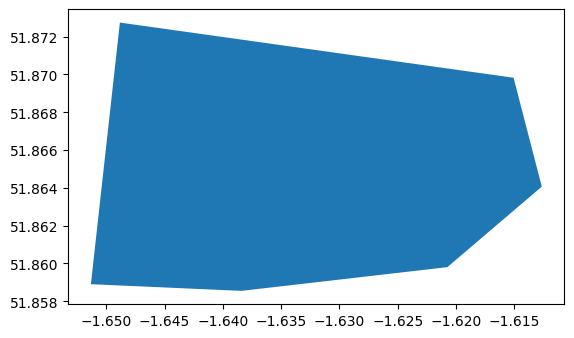

In [2]:
## Temporal extenct and area of interest 
# poi = ["2017-01-01", "2017-12-31"]
# aoi = gpd.read_file(wrkDir + 'EvenlodeNFMsite.kml')
# aoi = aoi[aoi.Name=='Evenlode NFM site']
# aoi = gpd.read_file("/Users/vm/Documents/Scripts and Data/data/spongeworks/East_Hendred_Fields.geojson") # polygon of stream 
aoi = gpd.read_file('/Users/vm/Desktop/dir/spongeworks/data/aoi.geojson')
aoi.plot()

## Bounding box
W = aoi.total_bounds[0]
S = aoi.total_bounds[1]
E = aoi.total_bounds[2]
N = aoi.total_bounds[3]

In [ ]:
# ## Get the years from the date range
# def get_years_from_date_range(poi):
#   """
#   Extracts the years from a list of date strings.

#   Args:
#     poi: A list of date strings in "YYYY-MM-DD" format.

#   Returns:
#     A list of unique years extracted from the input date strings.
#   """
#   years = set()
#   for date_str in poi:
#     date_obj = datetime.strptime(date_str, "%Y-%m-%d")
#     years.add(date_obj.year)
#   return sorted(list(years))

# yoi = get_years_from_date_range(poi)


In [ ]:
connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()
# List collections available on the openEO back-end
connection.list_collection_ids()
# Get detailed metadata of a certain collection
connection.describe_collection("SENTINEL2_L2A")

In [ ]:
# ## function to load geojson file
# def read_json(path: Path) -> dict:
#     with open(path) as input:
#         field = json.load(input)
#         input.close()
#     return field

In [ ]:
def assign_lon_lat_to_xarray(data, lon, lat):
    """
    Assigns longitude and latitude values to xarray's x and y coordinates.

    Args:
        lai_data (xr.Dataset): The xarray Dataset.
        lon (np.ndarray): 2D array of longitude values.
        lat (np.ndarray): 2D array of latitude values.

    Returns:
        xr.Dataset: The xarray Dataset with updated coordinates.
    """

    # Ensure lon and lat match the shape of the x and y dimensions.
    if lon.shape != (data.y.size, data.x.size) or lat.shape != (data.y.size, data.x.size):
        raise ValueError("lon and lat arrays do not match the shape of xarray's x and y dimensions.")

    # Extract 1D arrays to assign to x and y coordinates.
    new_lon_x = lon[0, :]  # First row of lon (representing x)
    new_lat_y = lat[:, 0]  # First column of lat (representing y)

    # Assign the new coordinates:
    data = data.assign_coords({"x": new_lon_x, "y": new_lat_y})

    return data

## Climate data 

In [ ]:
# for current_year in yoi: 

#     c = cdsapi.Client()

#     c.retrieve(
#         'reanalysis-era5-single-levels',
#         {
#             'product_type': 'reanalysis',
#             "data_format": "netcdf",
#             "download_format": "zip",       
#             'variable': [
#                 '2m_temperature', '2m_dewpoint_temperature',
#                 'surface_solar_radiation_downwards', 'total_precipitation',
#                 '10m_u_component_of_wind', '10m_v_component_of_wind',
#             ],
#             'year': [
#                 f'{current_year}',
#             ],
#             'month': [
#                 '01', '02', '03',
#                 '04', '05', '06',
#                 '07', '08', '09',
#                 '10', '11', '12',
#             ],
#             'day': [
#                 '01', '02', '03',
#                 '04', '05', '06',
#                 '07', '08', '09',
#                 '10', '11', '12',
#                 '13', '14', '15',
#                 '16', '17', '18',
#                 '19', '20', '21',
#                 '22', '23', '24',
#                 '25', '26', '27',
#                 '28', '29', '30',
#                 '31',
#             ],
#             'time': [
#                 '00:00', '01:00', '02:00',
#                 '03:00', '04:00', '05:00',
#                 '06:00', '07:00', '08:00',
#                 '09:00', '10:00', '11:00',
#                 '12:00', '13:00', '14:00',
#                 '15:00', '16:00', '17:00',
#                 '18:00', '19:00', '20:00',
#                 '21:00', '22:00', '23:00',
#             ],
#             'area': [N, W, S, E],
#         },
#         f'{base_path}/ERA5_{current_year}.zip')


In [ ]:
# def daylength(dayOfYear, lat):
# 	"""Computes the length of the day (the time between sunrise and
# 	sunset) given the day of the year and latitude of the location.
# 	* https://doi.org/10.1016/0304-3800(94)00034-F

# 	Parameters
# 	----------
# 	dayOfYear : int
# 		The day of the year. 1 corresponds to 1st of January
# 		and 365 to 31st December (on a non-leap year).
# 	lat : float
# 		Latitude of the location in degrees. Positive values
# 		for north and negative for south.

# 	Returns
# 	-------
# 	d : float
# 		Daylength in hours.
# 	"""

# 	latInRad = np.deg2rad(lat)
# 	declinationOfEarth = 23.45*np.sin(np.deg2rad(360.0*(283.0+dayOfYear)/365.0))
# 	if -np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth)) <= -1.0:
# 		return 24.0
# 	elif -np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth)) >= 1.0:
# 		return 0.0
# 	else:
# 		hourAngle = np.rad2deg(np.arccos(-np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth))))
# 		return 2.0*hourAngle/15.0


## Produce met_DF dataset
folders_met = []
for file in glob("/Users/vm/Documents/Scripts and Data/data/ERA5/*") : 
	folders_met.append(file)
folders_met.sort()

siteLat = aoi.geometry.centroid.y[0] #.centroid.y.iloc[0]
siteLon = aoi.geometry.centroid.x[0] #.centroid.x.iloc[0]

met_DF = pd.DataFrame(columns=['date','minT','maxT','srad','vpd','wind','photopd','21d_vpd','21d_minT','21d_photopd','prec'])

for ii in range(len(folders_met)):

	ds1 = xr.open_dataset(f"{folders_met[ii]}/data_stream-oper_stepType-instant.nc",engine='netcdf4')
	ds2 = xr.open_dataset(f"{folders_met[ii]}/data_stream-oper_stepType-accum.nc",engine='netcdf4')
	dsloc1 = ds1.sel(longitude=float(siteLon),latitude=float(siteLat),method='nearest') 
	dsloc2 = ds2.sel(longitude=float(siteLon),latitude=float(siteLat),method='nearest') 
	df1 = dsloc1.to_dataframe()
	df2 = dsloc2.to_dataframe()
	## unit conversion
	df1.t2m = df1.t2m - 273.15
	df1.d2m = df1.d2m - 273.15
	## relative humidity (http:/andrew.rsmas.miami.edu/bmcnoldy/Humidity.html)
	df1['RH'] = 100*(np.exp((17.625*df1.d2m)/(243.04+df1.d2m))/np.exp((17.625*df1.t2m)/(243.04+df1.t2m))) 
	## vapor pressure deficit (http:/cronklab.wikidot.com/calculation-of-vapour-pressure-deficit)
	df1['VPD'] = (1-(df1.RH/100)) * (610.7*10**(7.5*df1.t2m/(237.3+df1.t2m)))
	df1['windspeed'] = (df1.u10**2 + df1.v10**2)**0.5

	df1 = df1.reset_index()
	df1.index = pd.to_datetime(df1.valid_time)
	df1 = df1.drop(columns=['expver'])
	df2 = df2.reset_index()
	df2.index = pd.to_datetime(df2.valid_time)
	df2 = df2.drop(columns=['expver'])

	for t in range(len(df1.resample('D').mean())):
			met_DF = met_DF._append({'date' : (df1.resample('D').mean()).index[t],
									'doy'  : (df1.resample('D').mean()).index.dayofyear[t],
									# 'minT' : (df1.t2m.resample('D',label='left').min()).iloc[t],
									# 'maxT' : (df1.t2m.resample('D',label='left').max()).iloc[t],
									'avgT' : (df1.t2m.resample('D',label='left').mean()).iloc[t],
									'prec' : (df2.tp.resample('D',label='left').mean()).iloc[t], # * 1000 / 3600 , # m to mm.s-1 i.e. kg.rain.m-2.s-1
									# 'srad' : (df2.ssrd.resample('D',label='left').sum()).iloc[t] * 1e-6, # to MJ.m-2.d-1
									'wind' : (df1.windspeed.resample('D',label='left').mean()).iloc[t],
									'vpd'  : (df1.VPD.resample('D',label='left').mean()).iloc[t],
									# 'photopd': daylength((df1.resample('D').mean()).index.dayofyear[t],float(siteLat))
									},ignore_index=True)


# met_DF = met_DF.loc[poi[0][:4]:poi[1][:4]]

In [ ]:
met_DF

## NDWI from S2 Bands

In [ ]:

# First, we connect to the back-end and authenticate. 
connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()

sYear = 2024

for sYear in [2017,2024]: 
    
    poi = [f"{sYear}-01-01", f"{sYear}-12-31"]

    # Now that we are connected, we can initialize our datacube object with the area of interest 
    # and the time range of interest using Sentinel 1 data.
    datacube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent={"west": W, "south": S, "east": E, "north": N,}, # "crs": "EPSG:4326"
        temporal_extent = poi,
        bands=["B03","B08", "SCL"],
        max_cloud_cover=30,
    )

    # By filtering as early as possible (directly in load_collection() in this case), 
    # we make sure the back-end only loads the data we are interested in and avoid incurring unneeded costs.

    ## From this data cube, we can now select the individual bands with the DataCube.band() method and rescale the digital number values to physical reflectances:
    B03 = datacube.band("B03") * 0.0001
    B08 = datacube.band("B08") * 0.0001
    SCL = datacube.band("SCL") # Scene classification layer

    # Cloud masking using the SCL band
    cloud_mask =  ((SCL == 8) | (SCL == 9) | (SCL == 3)) * 1.0

    # Apply the cloud mask
    masked_cube = datacube.mask(cloud_mask)

    # Recalculate the bands after masking
    B03_masked = masked_cube.band("B03") * 0.0001
    B08_masked = masked_cube.band("B08") * 0.0001

    # Calculate NDWI
    ndwi_cube = (B03_masked-B08_masked) / (B03_masked+B08_masked)

    ndwi_cube.download(f'/Users/vm/Desktop/dir/spongeworks/data/ndwi_cube_{sYear}.nc', format="NetCDF")

# data = xr.open_dataset("/Users/vm/Desktop/ndwi_cube.nc",engine='netcdf4')
# transformer = Transformer.from_crs(data.crs.attrs['crs_wkt'], "epsg:4326", always_xy=True) 
# xv, yv = np.meshgrid(data.x, data.y)
# lon, lat = transformer.transform(xv, yv)
# data = assign_lon_lat_to_xarray(data, lon, lat)
# data.crs.attrs['crs_wkt'] = "epsg:4326"
# data.to_netcdf('/Users/vm/Desktop/ndwi_cube_reproj.nc',engine="netcdf4")

    sYear = 2017
    poi = [f"{sYear}-01-01", f"{sYear}-12-31"]

    # Second, we query the data collection and collect the data 
    datacube = connection.load_collection("SENTINEL1_GRD",
                                            spatial_extent={"west": W, "south": S, "east": E, "north": N,"crs": "EPSG:4326"},
                                            temporal_extent = poi, 
                                            bands=["VV","VH"])

    # Thrid, we calculate backsctter using the datacube
    s1_scatter = datacube.sar_backscatter(coefficient="sigma0-ellipsoid", elevation_model="COPERNICUS_30", noise_removal=True)
    s1bs = s1_scatter.apply(lambda x: 10 * x.log(base=10))

    # Fourth, we save to netcdf
    s1bs.download(f"/Users/vm/dir/spongeworks/data/sar_bs_{sYear}.nc")

In [ ]:
import xarray as xr
from pyproj import Transformer

# Paths to the datasets for both years
ndwi_paths = [
    "/Users/vm/Desktop/dir/spongeworks/data/ndwi_cube_2017.nc",
    "/Users/vm/Desktop/dir/spongeworks/data/ndwi_cube_2024.nc"
]
sar_paths = [
    "/Users/vm/Desktop/dir/spongeworks/data/sar_bs_2017.nc",
    "/Users/vm/Desktop/dir/spongeworks/data/sar_bs_2024.nc"
]

# Open and concatenate NDWI cubes along the time dimension
ndwi_datasets = [xr.open_dataset(p, engine="netcdf4") for p in ndwi_paths]
ndwi_all = xr.concat(ndwi_datasets, dim="t")

# Open and concatenate SAR backscatter cubes along the time dimension
sar_datasets = [xr.open_dataset(p, engine="netcdf4") for p in sar_paths]
sar_all = xr.concat(sar_datasets, dim="t")

# Save the joined datasets if needed
# Reproject ndwi_all to EPSG:4326
transformer_ndwi = Transformer.from_crs(ndwi_all.crs.attrs['crs_wkt'], "epsg:4326", always_xy=True)
xv_ndwi, yv_ndwi = np.meshgrid(ndwi_all.x, ndwi_all.y)
lon_ndwi, lat_ndwi = transformer_ndwi.transform(xv_ndwi, yv_ndwi)
ndwi_all = assign_lon_lat_to_xarray(ndwi_all, lon_ndwi, lat_ndwi)
ndwi_all.crs.attrs['crs_wkt'] = "epsg:4326"

# Reproject sar_all to EPSG:4326
transformer_sar = Transformer.from_crs(sar_all.crs.attrs['crs_wkt'], "epsg:4326", always_xy=True)
xv_sar, yv_sar = np.meshgrid(sar_all.x, sar_all.y)
lon_sar, lat_sar = transformer_sar.transform(xv_sar, yv_sar)
sar_all = assign_lon_lat_to_xarray(sar_all, lon_sar, lat_sar)
sar_all.crs.attrs['crs_wkt'] = "epsg:4326"
ndwi_all.to_netcdf("/Users/vm/Desktop/dir/spongeworks/data/ndwi.nc")
sar_all.to_netcdf("/Users/vm/Desktop/dir/spongeworks/data/sar_bs.nc")

In [ ]:
import hvplot.xarray

# Interactive plot with a slider for the 't' (time) dimension
ndwi_all.hvplot.image(
    x='x', y='y', z='var',
    frame_width=500, frame_height=400,
    cmap='Greens', clim=(-1, 1),
    title='NDWI (interactive, select date with slider)',
    groupby='t'
)

In [ ]:
data = xr.open_dataset(f"/Users/vm/Desktop/dir/spongeworks/data/ndwi_cube_{sYear}.nc",engine='netcdf4')
# transformer = Transformer.from_crs(data.crs.attrs['crs_wkt'], "epsg:4326", always_xy=True) 
# xv, yv = np.meshgrid(data.x, data.y)
# lon, lat = transformer.transform(xv, yv)
# data = assign_lon_lat_to_xarray(data, lon, lat)
# data.crs.attrs['crs_wkt'] = "epsg:4326"
# data.to_netcdf('/Users/vm/Desktop/dir/Spongeworks/data/ndwi_cube.nc',engine="netcdf4")

## Sentinel-1 SAR backscatter 

In [ ]:
# First, we connect to the back-end and authenticate. 
connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()

sYear = 2024
poi = [f"{sYear}-01-01", f"{sYear}-12-31"]

# Second, we query the data collection and collect the data 
datacube = connection.load_collection("SENTINEL1_GRD",
                                        spatial_extent={"west": W, "south": S, "east": E, "north": N,"crs": "EPSG:4326"},
                                        temporal_extent = poi, 
                                        bands=["VV","VH"])

# Thrid, we calculate backsctter using the datacube
s1_scatter = datacube.sar_backscatter(coefficient="sigma0-ellipsoid", elevation_model="COPERNICUS_30", noise_removal=True)
s1bs = s1_scatter.apply(lambda x: 10 * x.log(base=10))

# Fourth, we save to netcdf
s1bs.download(f"/Users/vm/Desktop/dir/spongeworks/data/sar_bs_{sYear}.nc")

# data = xr.open_dataset("/Users/vm/Desktop/sar_bs.nc",engine='netcdf4')
# transformer = Transformer.from_crs(data.crs.attrs['crs_wkt'], "epsg:4326", always_xy=True) 
# xv, yv = np.meshgrid(data.x, data.y)
# lon, lat = transformer.transform(xv, yv)
# data = assign_lon_lat_to_xarray(data, lon, lat)
# data.crs.attrs['crs_wkt'] = "epsg:4326"
# data.to_netcdf('/Users/vm/Desktop/sar_bs_reproj.nc',engine="netcdf4")

## Land cover 

In [10]:
import rioxarray

print(rioxarray.__version__)

0.15.0


/Users/vm/p312/lib/python3.12/site-packages/xarray/plot/utils.py:260: RuntimeWarning: overflow encountered in scalar absolute
  vlim = max(abs(vmin - center), abs(vmax - center))


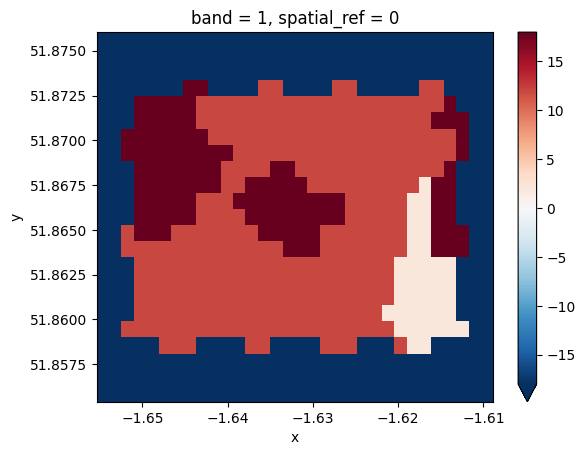

In [8]:
import rioxarray

# aoi = aoi.to_crs(4326)

# Open the raster with rioxarray (which supports .rio methods)
landcover = rioxarray.open_rasterio('/Users/vm/Downloads/Results-2/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif')

landcover[0,:,:].plot()

# Clip the raster to AOI geometry
# landcoverAOI = landcover.rio.clip(aoi.geometry, aoi.crs, drop=True)

In [15]:
MuW = gpd.read_file("/Users/vm/Desktop/dir/spongeworks/data/MuW.geojson")

In [33]:
import rioxarray

# Reproject ndwi_all to EPSG:4326 if not already
if not ndwi_all.rio.crs or ndwi_all.rio.crs.to_epsg() != 4326:
    ndwi_all = ndwi_all.rio.write_crs("EPSG:4326", inplace=False)
    ndwi_all = ndwi_all.rio.reproject("EPSG:4326")
ndwi_all


<xarray.Dataset> Size: 5MB
Dimensions:  (x: 270, y: 164, t: 30)
Coordinates:
  * x        (x) float64 2kB 5.928e+05 5.929e+05 ... 5.955e+05 5.955e+05
  * y        (y) float64 1kB 5.748e+06 5.748e+06 ... 5.746e+06 5.746e+06
  * t        (t) datetime64[ns] 240B 2017-01-02 2017-01-05 ... 2024-12-14
    crs      int64 8B 0
Data variables:
    var      (t, y, x) float32 5MB -0.5913 -0.6046 -0.6639 ... nan nan nan
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform

In [44]:
from shapely.geometry import mapping

# Reproject MuW to the CRS of ndwi_all (which is in meters, e.g., EPSG:32630 or similar)
ndwi_all = xr.open_dataset('/Users/vm/Desktop/dir/spongeworks/data/ndwi.nc')

target_crs = ndwi_all.rio.crs
MuW_proj = MuW.to_crs("EPSG:4326")

# Get the geometry of the first MuW polygon in the projected CRS
polygon_proj = MuW_proj.iloc[0].geometry
print(polygon_proj)
print("CRS of ndwi_all:", ndwi_all.rio.crs)
print("CRS of MuW_proj:", MuW_proj.crs)

# Now clip using the projected polygon
ndwi_all_crop = ndwi_all.rio.clip([polygon_proj], drop=True, invert=False)

POLYGON ((-1.616530453722163 51.86484037989962, -1.6164086674117186 51.864639831935136, -1.6139018992022045 51.865134933102155, -1.614318002426927 51.86549215461045, -1.616530453722163 51.86484037989962))
CRS of ndwi_all: None
CRS of MuW_proj: EPSG:4326


MissingCRS: CRS not found. Please set the CRS with 'rio.write_crs()'. Data variable: var

In [4]:
from shapely.geometry import box

waterways = gpd.read_file("/Users/vm/Downloads/oprvrs_essh_gb-2/data/WatercourseLink.shp")

# Ensure CRS is set for landcover
lc_crs = landcover.rio.crs

# Reproject waterways to match landcover CRS if needed
if waterways.crs != lc_crs:
    waterways = waterways.to_crs(lc_crs)

# Get the bounds of the landcover raster as a shapely box
lc_bounds = landcover.rio.bounds()
lc_box = box(*lc_bounds)

# Keep only waterways that intersect with the landcover extent
waterways_overlap = waterways[waterways.intersects(lc_box)]

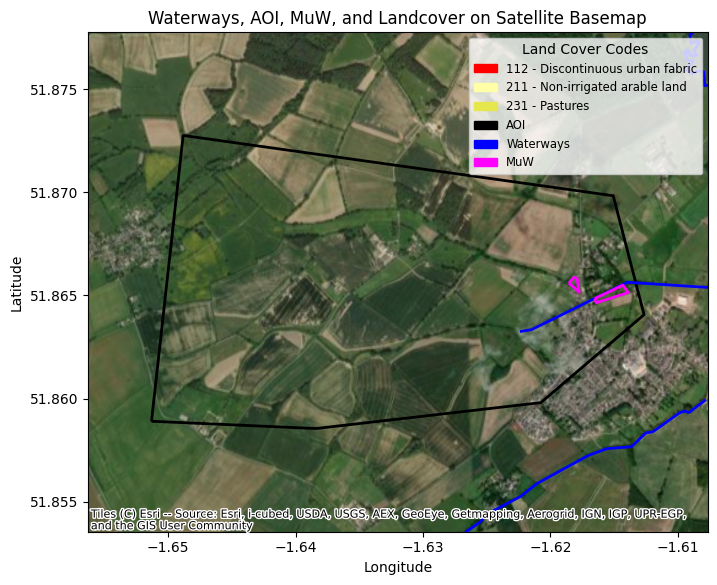

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

# Use the masked RGB image for correct landcover coloring
ax.imshow(
    rgb_img_masked,
    extent=[landcover.x.min(), landcover.x.max(), landcover.y.min(), landcover.y.max()],
    origin='upper'
)

# Plot AOI and waterways
aoi.boundary.plot(ax=ax, color='black', linewidth=2, label='AOI')
waterways_overlap.plot(ax=ax, color='blue', linewidth=2, label='Waterways')

# Plot MuW polygons
MuW.boundary.plot(ax=ax, color='magenta', linewidth=2, label='MuW')

# Set extent to AOI bounds with a small buffer
ax.set_xlim(W - buffer, E + buffer)
ax.set_ylim(S - buffer, N + buffer)

# Add satellite basemap
ctx.add_basemap(
    ax,
    crs=aoi.crs,
    source=ctx.providers.Esri.WorldImagery
)

# Build legend for only codes present in the data
patches = [
    mpatches.Patch(
        color=lc_code_to_color[code],
        label=lc_code_to_label[code]
    )
    for code in unique_codes if code in lc_code_to_color
]
patches += [
    mpatches.Patch(color='black', label='AOI'),
    mpatches.Patch(color='blue', label='Waterways'),
    mpatches.Patch(color='magenta', label='MuW')
]
ax.legend(handles=patches, loc='upper right', fontsize='small', title="Land Cover Codes", ncol=1)

plt.title("Waterways, AOI, MuW, and Landcover on Satellite Basemap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [ ]:
# xr.open_dataset("/Users/vm/Downloads/Results-2/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif")

## Plot 

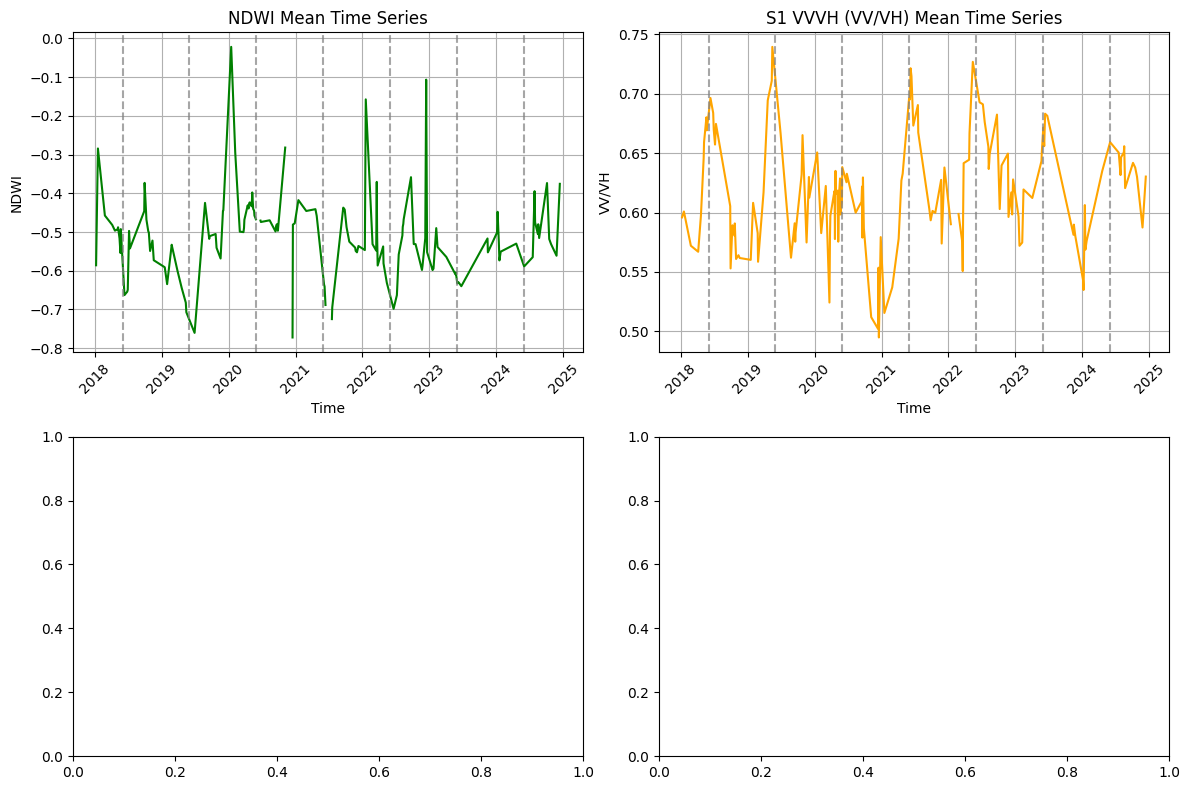

In [17]:
import matplotlib.dates as mdates

ndwi = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/ndwi_cube.nc',engine='netcdf4')
s1 = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/sar_bs.nc',engine='netcdf4')
s1['VVVH'] = s1.VV / s1.VH

# Compute mean values over the spatial dimensions for time series
ndwi_mean = ndwi["var"].mean(dim=["x", "y"])
s1_vv_mean = s1["VV"].mean(dim=["x", "y"])
s1_vh_mean = s1["VH"].mean(dim=["x", "y"])

# Compute mean VV/VH and interpolate to NDWI time axis
vvvh_mean = s1["VVVH"].mean(dim=["x", "y"])
vvvh_interp = vvvh_mean.interp(t=ndwi["var"]["t"])

# met_DF.index = pd.to_datetime(met_DF['date'])
# met_DF = met_DF['2018':'2024']
# Calculate cumulative precipitation that resets each 1 January
# total_prec_cum = met_DF['prec'].groupby(met_DF.index.year).cumsum()

# Get all June 1st dates in the time range for vertical lines
years = np.unique([pd.to_datetime(d).year for d in ndwi_mean["t"].values])
june_dates = [np.datetime64(f"{y}-06-01") for y in years]

# Create the figure and axes
fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1]})

# Plot time series of mean values
axes[0, 0].plot(ndwi_mean["t"].values, ndwi_mean.values, label="NDWI", color="green")
axes[0, 0].set_title("NDWI Mean Time Series")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("NDWI")
axes[0, 0].grid()
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0, 0].tick_params(axis='x', rotation=45)
for jd in june_dates:
    axes[0, 0].axvline(jd, color='grey', linestyle='--', alpha=0.7)

axes[0, 1].plot(ndwi_mean["t"].values, vvvh_interp.values, label="S1 VVVH (VV/VH)", color="orange")
axes[0, 1].set_title("S1 VVVH (VV/VH) Mean Time Series")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("VV/VH")
axes[0, 1].grid()
axes[0, 1].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0, 1].tick_params(axis='x', rotation=45)
for jd in june_dates:
    axes[0, 1].axvline(jd, color='grey', linestyle='--', alpha=0.7)


# # Plot cumulative precipitation
# axes[1, 0].plot(total_prec_cum.index, total_prec_cum.values, color="dodgerblue", label="Cumulative Precipitation")
# axes[1, 0].set_title("Cumulative Precipitation (reset yearly)")
# axes[1, 0].set_xlabel("Time")
# axes[1, 0].set_ylabel("Cumulative Precipitation (m)")
# axes[1, 0].grid()
# axes[1, 0].xaxis.set_major_locator(mdates.YearLocator())
# axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# axes[1, 0].tick_params(axis='x', rotation=45)
# for jd in june_dates:
#     axes[1, 0].axvline(jd, color='grey', linestyle='--', alpha=0.7)
# axes[1, 0].legend()

# # Plot total daily precipitation instead of cumulative
# axes[1, 1].plot(met_DF.index, met_DF['prec'], color="dodgerblue", label="Daily Precipitation")
# axes[1, 1].set_title("Total Daily Precipitation")
# axes[1, 1].set_xlabel("Time")
# axes[1, 1].set_ylabel("Precipitation (m)")
# axes[1, 1].grid()
# axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())
# axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# axes[1, 1].tick_params(axis='x', rotation=45)
# for jd in june_dates:
#     axes[1, 1].axvline(jd, color='grey', linestyle='--', alpha=0.7)
# axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# ndwi["var"].hvplot(
#     x='x', 
#     y='y', 
#     cmap='Greens', 
#     title='NDWI Map', 
#     clim=(ndwi["var"].min().item(), ndwi["var"].max().item())  # Set color scale limits
# )

In [ ]:
# ndwi["high"] = ndwi['var'].where(ndwi["var"]>=0)
# ndwi["high"].hvplot(
#     x='x', 
#     y='y', 
#     cmap='Greens', 
#     title='NDWI Map', 
# )

In [ ]:
ndwi = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/ndwi_cube.nc',engine='netcdf4')
ndwi = ndwi.rename_vars({'var':'ndwi'})
s1 = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/sar_bs.nc',engine='netcdf4')
s1['VVVH'] = s1.VV / s1.VH


output_dir = "ndwi_frames"
os.makedirs(output_dir, exist_ok=True)

# Read the GeoJSON file containing the stream feature
points = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/points.geojson')
# Transform the stream to the desired CRS
points.geometry = points.geometry.to_crs("EPSG:4326")
points = points.set_crs(4326,allow_override=True)  # Replace 4326 with the current CRS of the stream data

stream = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/stream.geojson')
stream.geometry = stream.geometry.to_crs("EPSG:4326")
stream = stream.set_crs(4326,allow_override=True)  # Replace 4326 with the current CRS of the stream data

# Get the global min and max values for the color scale
vmin = ndwi["ndwi"].min().item()
vmax = ndwi["ndwi"].max().item()

# Generate frames for each time step
time_steps = ndwi["t"]  # Replace "t" with the name of your time dimension
frame_paths = []

for i, time in enumerate(time_steps):

    # Create the plot for the current time step
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ndwi["ndwi"].sel(t=time).plot(cmap="vanimo_r", vmin=-1, vmax=1)  # Fix color scale
    
    # Add the stream feature as an overlay
    stream.plot(ax=ax, color="blue", linewidth=1, label="Stream")  # Customize color and line width
    points.plot(ax=ax, color="red", linewidth=1, label="Points")  # Customize color and line width

    # # Add a colorbar with a shrink factor to scale it proportionally
    # cbar = fig.colorbar(im, ax=ax, shrink=0.8)  # Adjust shrink to control colorbar size
    # cbar.set_label("NDWI Value")
    
    # Add title, labels, and legend
    ax.set_title(f"NDWI Map - Time: {str(pd.to_datetime(time.values))[:10]}", fontsize=14)
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.legend(loc="upper right")  # Add legend for the stream feature
    
    # Save the plot as a PNG file
    frame_path = os.path.join(output_dir, f"frame_{i:03d}.png")
    plt.savefig(frame_path, dpi=150)
    plt.close()
    frame_paths.append(frame_path)

# Create a .gif from the saved frames
gif_path = "/Users/vm/Desktop/ndwi_animation.gif"
with imageio.get_writer(gif_path, mode='I', duration=15) as writer:  # Adjust duration for frame speed
    for frame_path in frame_paths:
        image = imageio.imread(frame_path)
        writer.append_data(image)

print(f"Animation saved as {gif_path}")

# # Optional: Clean up temporary frame files
# for frame_path in frame_paths:
#     os.remove(frame_path)

In [ ]:
points = points[points.name.isin(['Bund-1','Bund-3'])]
# Loop through each point and crop ndwi and s1 datasets individually
cropped_results = []
buffer_deg  = 0.0001  # Buffer size in degrees
for idx, row in points.iterrows():
    # Get point coordinates
    pt = row.geometry
    # Buffer around the point (in degrees)
    minx, miny = pt.x - buffer_deg, pt.y - buffer_deg
    maxx, maxy = pt.x + buffer_deg, pt.y + buffer_deg

    # Crop ndwi and s1 datasets to the bounding box for this point
    ndwi_clip = ndwi.sel(x=slice(minx, maxx), y=slice(maxy, miny))
    s1_clip = s1.sel(x=slice(minx, maxx), y=slice(maxy, miny))

    cropped_results.append({
        "name": row["name"],
        "ndwi_cropped": ndwi_clip,
        "s1_cropped": s1_clip
    })

    print(f"{row['name']} - ndwi shape: {ndwi_clip['ndwi'].shape}, s1 shape: {s1_clip['VV'].shape}")
    # Save the clipped NDWI and S1 datasets for each point
    ndwi_clip.to_netcdf(f"{row['name']}_ndwi_clip.nc")
    s1_clip.to_netcdf(f"{row['name']}_s1_clip.nc")

In [ ]:
point_names = ["Bund-1", "Bund-3"]

for name in point_names:
    ndwi_cropped = xr.open_dataset(f"/Users/vm/Desktop/dir/Spongeworks/{name}_ndwi_clip.nc")
    s1_cropped = xr.open_dataset(f"/Users/vm/Desktop/dir/Spongeworks/{name}_s1_clip.nc")

    # Interpolate both NDWI and VV/VH means to a common time axis (NDWI's time)
    ndwi_cropped_mean = ndwi_cropped["ndwi"].mean(dim=["x", "y"])
    vvvh_cropped_mean = s1_cropped["VVVH"].mean(dim=["x", "y"])
    # Interpolate VV/VH to NDWI time
    vvvh_interp = vvvh_cropped_mean.interp(t=ndwi_cropped["t"])
    # Interpolate NDWI to NDWI time (identity, but for consistency)
    ndwi_interp = ndwi_cropped_mean.interp(t=ndwi_cropped["t"])

    fig, ax1 = plt.subplots(figsize=(10, 5))

    color1 = "forestgreen"
    color2 = "royalblue"

    ax1.set_xlabel("Time")
    ax1.set_ylabel("NDWI (mean)", color=color1)
    ax1.plot(
        ndwi_cropped_mean["t"].values,
        ndwi_interp.values,
        color=color1,
        label="NDWI (mean)",
        linewidth=2.5,
    )
    ax1.tick_params(axis="y", labelcolor=color1)

    ax2 = ax1.twinx()
    ax2.set_ylabel("VV/VH (mean, interpolated)", color=color2)
    ax2.plot(
        ndwi_cropped_mean["t"].values,
        vvvh_interp.values,
        color=color2,
        label="VV/VH (interp)",
        linewidth=2.5,
        linestyle="--",
    )
    ax2.tick_params(axis="y", labelcolor=color2)

    fig.tight_layout()
    plt.title(f"{name}: NDWI and VV/VH Mean Time Series")
    plt.show()


In [ ]:
import seaborn as sns
from scipy.stats import linregress

# Interpolate vvvh_cropped_mean to NDWI time for co-temporal points
vvvh_interp = vvvh_cropped_mean.interp(t=ndwi_cropped_mean["t"])

# Remove NaNs for scatter/hex plot
mask = (~np.isnan(ndwi_cropped_mean.values)) & (~np.isnan(vvvh_interp.values))
x = ndwi_cropped_mean.values[mask]
y = vvvh_interp.values[mask]

plt.figure(figsize=(7, 5))
g = sns.jointplot(x=x, y=y, kind="hex", color="teal", height=6)

# Overlay actual data points
g.ax_joint.scatter(x, y, color="red", s=18, alpha=0.7, label="Data points")

g.ax_joint.legend(loc="upper left")
g.set_axis_labels("NDWI (mean, cropped)", "VV/VH (mean, cropped, co-temporal)")
plt.suptitle("Hexbin plot of NDWI vs VV/VH (co-temporal)", y=1.02)
plt.show()


In [ ]:
landcover = xr.open_dataset 

## Land Cover 


In [ ]:
import json
import joblib
import requests as r
from glob import glob
import time
import rioxarray
import gc
from datetime import datetime, timedelta
import warnings

import openeo
import earthaccess

WRK_DIR = '/Users/vm/Desktop/dir/spongeworks/data/'
IN_DIR = os.path.join(WRK_DIR, 'eo')
AOI_JSON = '/Users/vm/Desktop/dir/spongeworks/data/aoi.geojson'
API_URL = 'https://appeears.earthdatacloud.nasa.gov/api/'
USER = os.getenv('APPEEARS_USER', 'vmyrg')
PASSWORD = os.getenv('APPEEARS_PASSWORD', 'CU5-HxX-HyT-AfU')
TASK_NAME = 'spongeworks_modis'
OUTPUT_FORMAT = 'netcdf4'
START_DATE = '01-01-2017'
END_DATE = '01-01-2025'
    
if not os.path.exists(IN_DIR):
    os.makedirs(IN_DIR)
os.chdir(IN_DIR)

if os.path.exists(os.path.join(IN_DIR, TASK_NAME)):
    print(f"Data already exists at {os.path.join(IN_DIR, TASK_NAME)}. Skipping download and processing.")
else:
    # ... (Your existing AppEEARS download logic goes here, unchanged) ...
    # --- Authenticate with AppEEARS API ---
    token_response = r.post(f'{API_URL}login', auth=(USER, PASSWORD)).json()
    token = token_response['token']
    headers = {'Authorization': f'Bearer {token}'}

    # --- Get available products from AppEEARS ---
    product_response = r.get(f'{API_URL}product').json()
    print(f"AρρEEARS currently supports {len(product_response)} products.")
    products = {p['ProductAndVersion']: p for p in product_response}

    # --- Helper: Search products by keyword in description ---
    def print_products_by_keyword(keyword):
        for p in product_response:
            if keyword in p['Description']:
                pprint.pprint(p)

    # --- Select layers to download (GPP, LAI, FPAR, Land Cover) ---
    layers = []
    # LAI
    X_product = 'MCD15A2H.061'
    layers.append({'product': X_product, 'layer': 'Lai_500m'})
    # FPAR
    X_product = 'MCD15A2H.061'
    X_layers = ['Fpar_500m']
    for layer in X_layers:
        layers.append({'product': X_product, 'layer': layer})
    # Land Cover
    X_product = 'MCD12Q1.061'
    X_layers = ['LC_Type5','QC']
    for layer in X_layers:
        layers.append({'product': X_product, 'layer': layer})

    # --- Read AOI as GeoJSON and get projection ---
    nps = gpd.read_file(AOI_JSON)
    if nps.empty:
        raise ValueError(f"The AOI file '{AOI_JSON}' is empty or invalid.")
    nps_json = json.loads(nps.to_json())
    projections = r.get(f'{API_URL}spatial/proj').json()
    projs = {p['Name']: p for p in projections}
    projection_name = projs['geographic']['Name']

    # --- Build and submit AppEEARS area task ---
    task = {
        'task_type': 'area',
        'task_name': TASK_NAME,
        'params': {
            'dates': [{'startDate': START_DATE, 'endDate': END_DATE}], # collect MODIS data 2000-2017 if simulation starts < 2017
            'layers': layers,
            'output': {
                'format': {'type': OUTPUT_FORMAT},
                'projection': projection_name
            },
            'geo': nps_json,
        }
    }
    task_response = r.post(f'{API_URL}task', json=task, headers=headers).json()
    if "task_id" in task_response:
        task_id = task_response["task_id"]
        print("Task submitted:", task_id)
    else:
        print("Task submission failed:", task_response.get("message", task_response))
        raise RuntimeError(f"Task submission failed: {task_response.get('message', task_response)}")

    # --- Wait for AppEEARS task to complete ---
    def wait_for_task_completion(api_url, task_id, headers):
        while True:
            resp = r.get(f'{api_url}task/{task_id}', headers=headers).json()
            if 'status' in resp:
                status = resp['status']
                print("Task status:", status)
                if status == 'done':
                    break
            else:
                print("Unexpected response:", resp)
                break
            time.sleep(20)
    wait_for_task_completion(API_URL, task_id, headers)

    # --- Download AppEEARS results to local directory ---
    dest_dir = os.path.join(IN_DIR, TASK_NAME)
    os.makedirs(dest_dir, exist_ok=True)
    bundle = r.get(f'{API_URL}bundle/{task_id}', headers=headers).json()
    files = {f['file_id']: f['file_name'] for f in bundle['files']}
    for file_id, file_name in files.items():
        dl = r.get(f'{API_URL}bundle/{task_id}/{file_id}', headers=headers, stream=True)
        filename = file_name.split('/')[1] if file_name.endswith('.tif') else file_name
        filepath = os.path.join(dest_dir, filename)
        with open(filepath, 'wb') as f:
            for chunk in dl.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f'Downloaded files can be found at: {dest_dir}')

In [ ]:
LC = xr.open_dataset("/Users/vm/Desktop/dir/spongeworks/data/eo/spongeworks_modis/MCD12Q1.061_500m_aid0001.nc")
LC 

In [ ]:
import matplotlib
import hvplot.xarray

# Extract the land cover type variable (assuming 'LC_Type5' is the variable name)
lc_type = LC['LC_Type5']

# Get the mapping of class values to names from attributes
lc_names = lc_type.attrs.get('flag_values', None)
lc_labels = lc_type.attrs.get('flag_meanings', None)

if lc_names is not None and lc_labels is not None:
    if isinstance(lc_names, str):
        lc_names = [int(x) for x in lc_names.split()]
    if isinstance(lc_labels, str):
        lc_labels = lc_labels.split()

    cmap = matplotlib.cm.get_cmap('tab20', len(lc_names))
    color_mapping = {v: matplotlib.colors.rgb2hex(cmap(i)) for i, v in enumerate(lc_names)}

    lc_type.hvplot.image(
        x='lon', y='lat', z='LC_Type5',
        cmap=[color_mapping[v] for v in lc_names],
        colorbar=True,
        clim=(min(lc_names), max(lc_names)),
        frame_width=600,
        frame_height=500,
        title='Land Cover (LC_Type5)',
        xlabel='Longitude',
        ylabel='Latitude'
    )
else:
    lc_type.hvplot.image(
        x='lon', y='lat', z='LC_Type5',
        cmap='tab20',
        colorbar=True,
        frame_width=600,
        frame_height=500,
        title='Land Cover (LC_Type5)',
        xlabel='Longitude',
        ylabel='Latitude'
    )


In [ ]:
LC.LC_Type5[0,:,:].plot()